# UNet++ Segmentation — E-Waste PCB Components

**Dataset:** `U-NET-segmentation-.v3i.coco/` (COCO polygon format)  
**Classes:** board, capacitor, chip, knob (+ background)  
**Model:** UNet++ with EfficientNet-B7 encoder pretrained on ImageNet  
**Accuracy metric:** Dice Coefficient (foreground classes)

**Folder assumption:** this notebook sits in the same folder as `U-NET-segmentation-.v3i.coco/`
```
your_folder/
├── unet_ewaste.ipynb       ← this file
└── U-NET-segmentation-.v3i.coco/
    ├── train/
    │   ├── *.jpg
    │   └── _annotations.coco.json
    ├── valid/
    │   ├── *.jpg
    │   └── _annotations.coco.json
    └── test/
        ├── *.jpg
        └── _annotations.coco.json
```


## 1. Install dependencies

In [1]:
%pip install segmentation-models-pytorch albumentations pycocotools timm


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Imports

In [2]:
import os
import json
import random
import numpy as np
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from pycocotools.coco import COCO

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')


Using device: cpu


## 3. Paths — notebook sits next to the dataset folder

In [3]:
DATASET_DIR = Path('U-NET-segmentation-.v3i.coco')

TRAIN_DIR = DATASET_DIR / 'train'
VALID_DIR = DATASET_DIR / 'valid'
TEST_DIR  = DATASET_DIR / 'test'

TRAIN_JSON = TRAIN_DIR / '_annotations.coco.json'
VALID_JSON = VALID_DIR / '_annotations.coco.json'
TEST_JSON  = TEST_DIR  / '_annotations.coco.json'

for p in [TRAIN_JSON, VALID_JSON, TEST_JSON]:
    status = 'OK' if p.exists() else 'MISSING'
    print(f'[{status}] {p}')

with open(TRAIN_JSON) as f:
    coco_data = json.load(f)

CATEGORIES  = [c for c in coco_data['categories'] if c['name'] != 'YOLO']
CLASSES     = [c['name'] for c in CATEGORIES]
NUM_CLASSES = len(CLASSES)   # 4: board, capacitor, chip, knob

print(f'\nClasses ({NUM_CLASSES}):', CLASSES)
print('Total annotations in train JSON:', len(coco_data['annotations']))


[OK] U-NET-segmentation-.v3i.coco/train/_annotations.coco.json
[OK] U-NET-segmentation-.v3i.coco/valid/_annotations.coco.json
[OK] U-NET-segmentation-.v3i.coco/test/_annotations.coco.json

Classes (4): ['board', 'capacitor', 'chip', 'knob']
Total annotations in train JSON: 393


## 4. Dataset class

In [4]:
class COCOSegDataset(Dataset):
    """
    Reads COCO-format polygon segmentation annotations and converts them
    to pixel masks. Pixel value = class index (0 = background).
    """
    def __init__(self, img_dir, json_path, transform=None):
        self.img_dir   = Path(img_dir)
        self.coco      = COCO(str(json_path))
        self.transform = transform

        all_cats  = self.coco.loadCats(self.coco.getCatIds())
        real_cats = [c for c in all_cats if c['name'] != 'YOLO']
        self.cat_to_idx = {c['id']: i + 1 for i, c in enumerate(real_cats)}

        valid_cat_ids = set(self.cat_to_idx.keys())
        ann_img_ids = set(
            ann['image_id'] for ann in self.coco.dataset['annotations']
            if ann['category_id'] in valid_cat_ids
        )
        self.img_ids = [iid for iid in self.coco.imgs.keys() if iid in ann_img_ids]

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id   = self.img_ids[idx]
        img_info = self.coco.imgs[img_id]
        img_path = self.img_dir / img_info['file_name']

        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        mask = np.zeros((h, w), dtype=np.uint8)
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns    = self.coco.loadAnns(ann_ids)

        # Paint large objects first (board), then small components on top
        anns = sorted(anns, key=lambda a: a.get('area', 0), reverse=True)

        for ann in anns:
            cat_id = ann['category_id']
            if cat_id not in self.cat_to_idx:
                continue

            cls_idx = self.cat_to_idx[cat_id]
            seg     = ann.get('segmentation', [])

            if seg and isinstance(seg, list) and all(len(s) >= 6 for s in seg):
                try:
                    rle_mask = self.coco.annToMask(ann)
                    mask[rle_mask == 1] = cls_idx
                except Exception as e:
                    print(f'Skipping ann_id={ann["id"]} polygon error: {e}')
                    continue
            else:
                bbox = ann.get('bbox', [])
                if len(bbox) == 4:
                    x, y, bw, bh = [int(v) for v in bbox]
                    x2 = min(x + bw, w)
                    y2 = min(y + bh, h)
                    mask[y:y2, x:x2] = cls_idx

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug['image']
            mask = aug['mask'].long()

        return img, mask


## 5. Transforms and dataloaders

**Image size:** 640 px — captures fine PCB detail that 512 loses, while staying
within the RTX 2080 Super VRAM budget at batch size 4 with EfficientNet-B7.

**EfficientNet-B7** was trained on 600 px images (its native resolution), so 640
is the closest practical match and avoids the aliasing you get when downscaling
to 512.


In [7]:
# 640 is EfficientNet-B7's native resolution; also retains fine PCB detail
IMG_SIZE    = 640
BATCH_SIZE  = 4   # reduce to 2 if VRAM OOM; increase to 8 if you have >16 GB
NUM_WORKERS = 0   # set 0 on Mac/Windows if multiprocessing issues arise

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    # Geometric augmentations
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=30, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.ElasticTransform(alpha=1, sigma=50, p=0.2),
    # Colour / texture augmentations
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1, p=0.5),
    A.GaussNoise(var_limit=(10, 50), p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.CLAHE(clip_limit=4.0, p=0.3),          # helps with PCB under-/over-exposure
    A.RandomBrightnessContrast(p=0.3),
    # Regularisation
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

train_ds = COCOSegDataset(TRAIN_DIR, TRAIN_JSON, train_transform)
valid_ds = COCOSegDataset(VALID_DIR, VALID_JSON, val_transform)
test_ds  = COCOSegDataset(TEST_DIR,  TEST_JSON,  val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train: {len(train_ds)} | Valid: {len(valid_ds)} | Test: {len(test_ds)}')


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Train: 59 | Valid: 17 | Test: 8


/var/folders/39/kz5fyl2s62q4v6wpq8nb7lpc0000gn/T/ipykernel_34816/616477304.py:16: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.3),
/var/folders/39/kz5fyl2s62q4v6wpq8nb7lpc0000gn/T/ipykernel_34816/616477304.py:21: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.3),


## 6. Visualise a batch — sanity check masks

/var/folders/39/kz5fyl2s62q4v6wpq8nb7lpc0000gn/T/ipykernel_34816/724689696.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10 = cm.get_cmap('tab10')


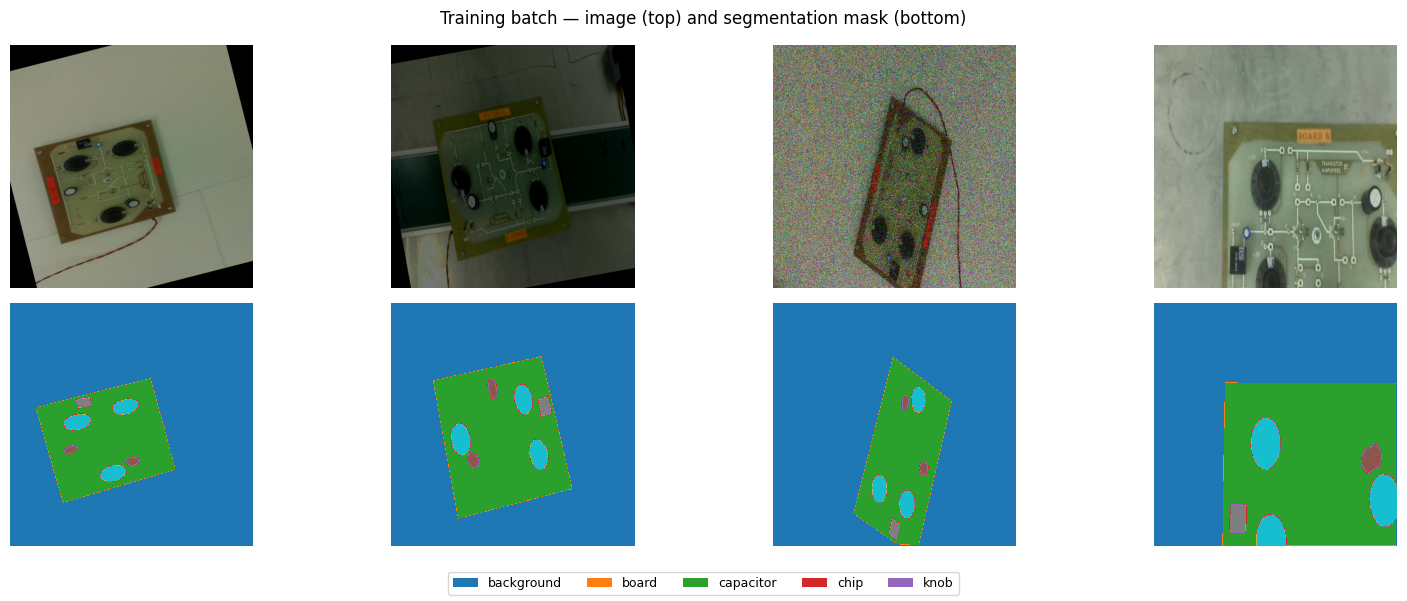

Class indices present in this batch: [0, 1, 2, 3, 4]
Expected: 0=bg, 1=board, 2=capacitor, 3=chip, 4=knob
  Image 0: classes present = [0, 1, 2, 3, 4]
  Image 1: classes present = [0, 1, 2, 3, 4]
  Image 2: classes present = [0, 1, 3, 4]
  Image 3: classes present = [0, 1, 2, 3, 4]


In [8]:
imgs, masks = next(iter(train_loader))

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

n = min(4, BATCH_SIZE)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 6))

for i in range(n):
    img_show = (imgs[i] * std + mean).permute(1, 2, 0).numpy().clip(0, 1)
    axes[0, i].imshow(img_show);  axes[0, i].axis('off')
    axes[1, i].imshow(masks[i].numpy(), cmap='tab10', vmin=0, vmax=NUM_CLASSES)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Image', fontsize=11)
axes[1, 0].set_ylabel('Mask',  fontsize=11)

from matplotlib.patches import Patch
import matplotlib.cm as cm
tab10 = cm.get_cmap('tab10')
legend_items = [Patch(facecolor=tab10(0), label='background')]
for i, cls in enumerate(CLASSES):
    legend_items.append(Patch(facecolor=tab10(i + 1), label=cls))
fig.legend(handles=legend_items, loc='lower center', ncol=5, fontsize=9)

plt.suptitle('Training batch — image (top) and segmentation mask (bottom)')
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

# Numeric check
imgs, masks = next(iter(train_loader))
print('Class indices present in this batch:', masks.unique().tolist())
print('Expected: 0=bg, 1=board, 2=capacitor, 3=chip, 4=knob')
for i in range(len(masks)):
    unique = masks[i].unique().tolist()
    print(f'  Image {i}: classes present = {unique}')


## 7. Build UNet++ model

**Why UNet++?**  
UNet++ adds dense skip connections between encoder and decoder at every depth,
reducing the semantic gap between merged feature maps. This consistently improves
Dice/IoU by 2–5 pp on small, detail-rich datasets like PCB components.

**Why EfficientNet-B7?**  
EfficientNet-B7 (66 M params) compound-scales width, depth, and resolution jointly,
giving it richer multi-scale representations than ResNet-34 (21 M) or even ResNet-50.
It's the strongest encoder in the EfficientNet family that fits a 2080 Super at 640 px.


In [9]:
model = smp.UnetPlusPlus(
    encoder_name        = 'efficientnet-b7',   # strongest EfficientNet; ~66 M params
    encoder_weights     = 'imagenet',
    encoder_depth       = 5,
    decoder_channels    = (256, 128, 64, 32, 16),
    in_channels         = 3,
    classes             = NUM_CLASSES + 1,     # +1 for background
    activation          = None,                # raw logits
    decoder_attention_type = 'scse',           # Squeeze-and-Channel-Excitation on decoder
)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params / 1e6:.1f} M')
print(f'Trainable parameters: {trainable_params / 1e6:.1f} M')
print(f'Model architecture  : UNet++ / EfficientNet-B7 / scSE decoder attention')


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/267M [00:00<?, ?B/s]

Total parameters    : 68.4 M
Trainable parameters: 68.4 M
Model architecture  : UNet++ / EfficientNet-B7 / scSE decoder attention


## 8. Loss function, optimiser, scheduler

**Loss:** 0.5 × DiceLoss + 0.5 × CrossEntropyLoss  
- Dice directly optimises the Dice Coefficient (our accuracy metric)
- CrossEntropy provides pixel-level gradient signal, stabilising early training

**Optimiser:** AdamW with differential learning rates  
- Encoder (pretrained) gets 10× lower LR than the decoder  
- Weight decay 1e-4 as regulariser

**Scheduler:** CosineAnnealingWarmRestarts (SGDR)  
- Warm restarts help escape local minima; better than plain CosineAnnealing for UNet++


In [10]:
dice_loss = smp.losses.DiceLoss(mode='multiclass', from_logits=True)
ce_loss   = nn.CrossEntropyLoss()

def combined_loss(preds, targets):
    return 0.5 * dice_loss(preds, targets) + 0.5 * ce_loss(preds, targets)

# Differential LRs: encoder (pretrained) gets 10x lower LR
encoder_params = list(model.encoder.parameters())
decoder_params = [p for n, p in model.named_parameters()
                  if not n.startswith('encoder')]

optimizer = torch.optim.AdamW([
    {'params': encoder_params, 'lr': 1e-5},   # pretrained — fine-tune gently
    {'params': decoder_params, 'lr': 1e-4},   # randomly initialised — train faster
], weight_decay=1e-4)

# CosineAnnealingWarmRestarts: T_0 restarts every 20 epochs, T_mult doubles period
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=20, T_mult=2, eta_min=1e-6
)

print('Loss, optimizer (differential LR), and scheduler (SGDR) ready.')


Loss, optimizer (differential LR), and scheduler (SGDR) ready.


## 9. Dice coefficient metric

In [11]:
def dice_coefficient(preds, targets, num_classes, smooth=1e-6):
    """
    Mean Dice Coefficient across foreground classes (skips background).

    Dice = 2 * |Pred ∩ GT| / (|Pred| + |GT|)
    Returns scalar in [0, 1]; 1.0 = perfect segmentation.
    """
    preds = preds.argmax(dim=1)   # (B, H, W)
    dices = []
    for c in range(1, num_classes + 1):   # skip background (0)
        pred_c   = (preds   == c).float()
        target_c = (targets == c).float()
        inter    = (pred_c * target_c).sum()
        total    = pred_c.sum() + target_c.sum()
        if total > 0:
            dices.append(((2.0 * inter + smooth) / (total + smooth)).item())
    return float(np.mean(dices)) if dices else 0.0

print('Dice coefficient helper defined.')
print('  Range: [0, 1] — higher is better; 1.0 = perfect.')


Dice coefficient helper defined.
  Range: [0, 1] — higher is better; 1.0 = perfect.


## 10. Training loop

In [ ]:
EPOCHS    = 100
SAVE_PATH = Path('unetpp_efficientnetb7_best.pth')

# Mixed-precision scaler for faster training on RTX 2080 Super
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

history  = {'train_loss': [], 'val_loss': [], 'val_dice': []}
best_dice = 0.0

for epoch in range(1, EPOCHS + 1):

    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    train_losses = []

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            preds = model(imgs)
            loss  = combined_loss(preds, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clip
        scaler.step(optimizer)
        scaler.update()
        train_losses.append(loss.item())

    # ── Validate ───────────────────────────────────────────────────────────
    model.eval()
    val_losses, val_dices = [], []

    with torch.no_grad():
        for imgs, masks in valid_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                preds = model(imgs)
            val_losses.append(combined_loss(preds, masks).item())
            val_dices.append(dice_coefficient(preds.cpu(), masks.cpu(), NUM_CLASSES))

    scheduler.step()

    t_loss = np.mean(train_losses)
    v_loss = np.mean(val_losses)
    v_dice = np.mean(val_dices)
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['val_dice'].append(v_dice)

    if v_dice > best_dice:
        best_dice = v_dice
        torch.save(model.state_dict(), SAVE_PATH)
        saved = '[BEST — saved]'
    else:
        saved = ''

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS}  '
              f'train_loss: {t_loss:.4f}  '
              f'val_loss: {v_loss:.4f}  '
              f'val_Dice: {v_dice:.4f}  {saved}')

print(f'\nDone. Best val Dice: {best_dice:.4f}  Weights saved to: {SAVE_PATH}')


/var/folders/39/kz5fyl2s62q4v6wpq8nb7lpc0000gn/T/ipykernel_34816/3926560951.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))
/var/folders/39/kz5fyl2s62q4v6wpq8nb7lpc0000gn/T/ipykernel_34816/3926560951.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):


## 11. Training curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train loss')
axes[0].plot(history['val_loss'],   label='Val loss')
axes[0].set_title('Loss (0.5×Dice + 0.5×CE)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['val_dice'], color='green', label='Val mean Dice')
axes[1].set_title('Validation mean Dice Coefficient')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('UNet++ / EfficientNet-B7 — training curves')
plt.tight_layout()
plt.show()

print(f'Best val Dice: {max(history["val_dice"]):.4f}  '
      f'(epoch {history["val_dice"].index(max(history["val_dice"])) + 1})')


## 12. Test set inference and visualisation

In [ ]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

PALETTE = np.array([
    [  0,   0,   0],   # 0 background
    [255,  56,  56],   # 1 board
    [255, 157,  56],   # 2 capacitor
    [ 56, 255, 157],   # 3 chip
    [ 56, 157, 255],   # 4 knob
], dtype=np.uint8)

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

n_show = min(4, len(test_ds))
fig, axes = plt.subplots(3, n_show, figsize=(4 * n_show, 9))

test_iter = iter(test_loader)
for col in range(n_show):
    imgs, masks = next(test_iter)
    imgs, masks = imgs.to(device), masks.to(device)

    with torch.no_grad():
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            pred_mask = model(imgs).argmax(dim=1).squeeze().cpu().numpy()

    img_show   = (imgs[0].cpu() * std + mean).permute(1, 2, 0).numpy().clip(0, 1)
    gt_mask    = masks[0].cpu().numpy()
    pred_color = PALETTE[pred_mask]
    gt_color   = PALETTE[gt_mask]

    axes[0, col].imshow(img_show);    axes[0, col].axis('off')
    axes[1, col].imshow(gt_color);    axes[1, col].axis('off')
    axes[2, col].imshow(pred_color);  axes[2, col].axis('off')

axes[0, 0].set_ylabel('Image',        fontsize=10)
axes[1, 0].set_ylabel('Ground truth', fontsize=10)
axes[2, 0].set_ylabel('Prediction',   fontsize=10)

plt.suptitle('UNet++ / EfficientNet-B7 — test set results', fontsize=13)
plt.tight_layout()
plt.show()


## 13. Per-class Dice Coefficient on test set

In [ ]:
smooth = 1e-6

per_class_inter = np.zeros(NUM_CLASSES + 1, dtype=np.float64)
per_class_total = np.zeros(NUM_CLASSES + 1, dtype=np.float64)  # |Pred| + |GT|

model.eval()
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs = imgs.to(device)
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            preds = model(imgs).argmax(dim=1).squeeze().cpu().numpy()
        gt = masks.squeeze().numpy()

        for c in range(1, NUM_CLASSES + 1):
            pred_c   = (preds == c).astype(np.float64)
            target_c = (gt    == c).astype(np.float64)
            per_class_inter[c] += (pred_c * target_c).sum()
            per_class_total[c] += pred_c.sum() + target_c.sum()

print('Per-class Dice Coefficient on test set:')
print('-' * 35)
dices = []
for c, cls_name in enumerate(CLASSES, start=1):
    if per_class_total[c] > 0:
        dice = (2.0 * per_class_inter[c] + smooth) / (per_class_total[c] + smooth)
        dices.append(dice)
        bar = '█' * int(dice * 30)
        print(f'  {cls_name:12s}: {dice:.4f}  {bar}')
    else:
        print(f'  {cls_name:12s}: N/A (not present in test set)')

print('-' * 35)
print(f'  Mean Dice   : {np.mean(dices):.4f}')
print(f'\nInterpretation: >0.85 = excellent | 0.70–0.85 = good | <0.70 = needs work')
